# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

Вариант 2: задания 1 и 2 на наборе данных MNIST

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [21]:
import random
import numpy as np
import matplotlib.pyplot as plt


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [22]:
from sklearn.datasets import load_digits
digits = load_digits()

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42
)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (1437, 64)
Training labels shape:  (1437,)
Test data shape:  (360, 64)
Test labels shape:  (360,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



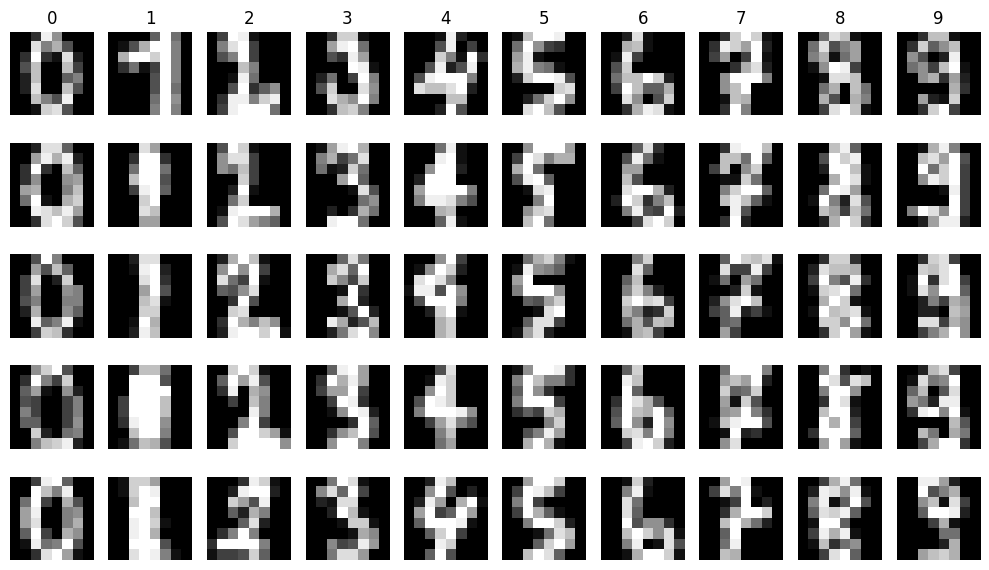

In [24]:
classes = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
num_classes = 10
samples_per_class = 5

plt.figure(figsize=(10, 6))

for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].reshape(8, 8), cmap='gray')
        plt.axis('off')
        
        if i == 0:
            plt.title(cls)

plt.tight_layout()
plt.show()

1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [25]:
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))

1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [26]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [27]:
y_test_pred = classifier.predict(X_test, k=3, num_loops=0)

1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


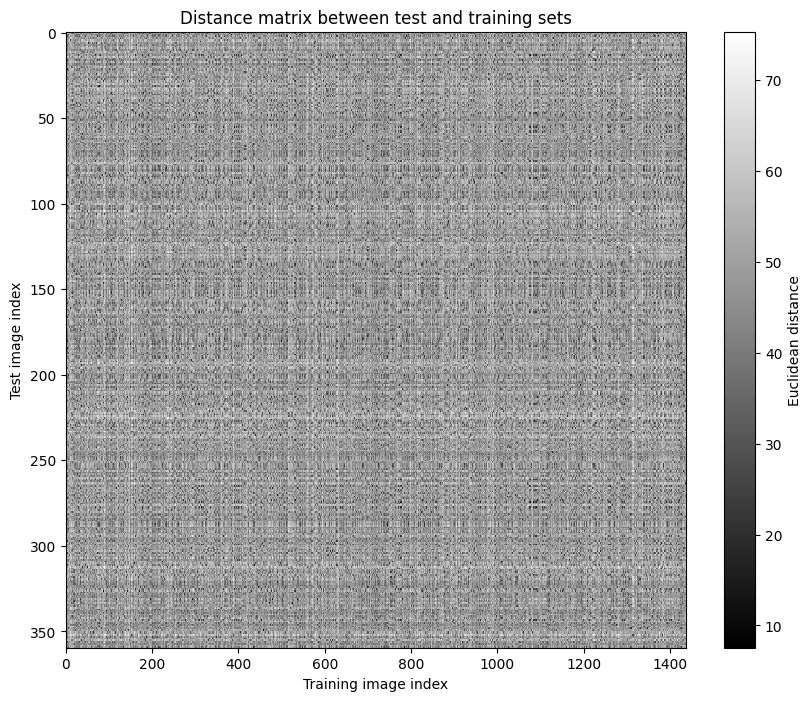

In [28]:
dists = classifier.compute_distances_no_loops(X_test)
plt.figure(figsize=(10, 8))
plt.imshow(dists, interpolation='nearest', aspect='auto')
plt.colorbar(label='Euclidean distance')
plt.title('Distance matrix between test and training sets')
plt.xlabel('Training image index')
plt.ylabel('Test image index')
plt.show()


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [29]:
num_correct = np.sum(y_test_pred == y_test)
num_test = len(y_test)
accuracy = float(num_correct) / num_test

print(f'accuracy: {accuracy:.4f}')

accuracy: 0.9833


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

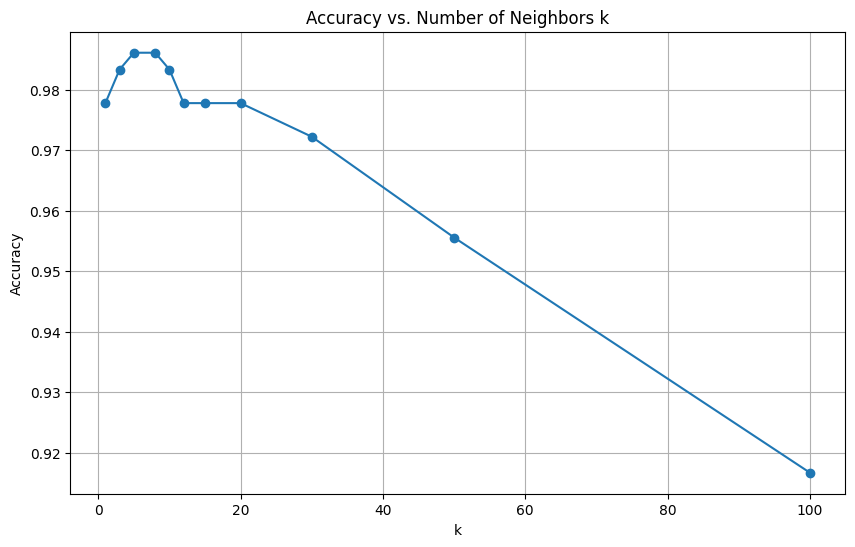

In [30]:
k_values = [1, 3, 5, 8, 10, 12, 15, 20, 30, 50, 100]
accuracies = []

for k in k_values:
    y_test_pred = classifier.predict_labels(dists, k=k)
    accuracy = np.mean(y_test_pred == y_test)
    accuracies.append(accuracy)

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-')
plt.title('Accuracy vs. Number of Neighbors k')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


In [31]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 30, 50, 100]
X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)
cv_results = {}

for k in k_choices:
    cv_results[k] = []
    for i in range(num_folds):
        X_val_fold = X_train_folds[i]
        y_val_fold = y_train_folds[i]
        X_train_fold = np.concatenate(X_train_folds[:i] + X_train_folds[i+1:])
        y_train_fold = np.concatenate(y_train_folds[:i] + y_train_folds[i+1:])
        classifier = KNearestNeighbor()
        classifier.train(X_train_fold, y_train_fold)
        y_val_pred = classifier.predict(X_val_fold, k=k, num_loops=0)
        accuracy = np.mean(y_val_pred == y_val_fold)
        cv_results[k].append(accuracy)

for k in sorted(cv_results):
    for accuracy in cv_results[k]:
        print(f'k = {k}, accuracy = {accuracy:.4f}')

best_k = None
best_accuracy = -1

for k, acc_list in cv_results.items():
    avg_acc = np.mean(acc_list)
    if avg_acc > best_accuracy:
        best_accuracy = avg_acc
        best_k = k

print(f'best k: {best_k}')

k = 1, accuracy = 0.9896
k = 1, accuracy = 0.9826
k = 1, accuracy = 0.9826
k = 1, accuracy = 0.9930
k = 1, accuracy = 0.9826
k = 3, accuracy = 0.9965
k = 3, accuracy = 0.9757
k = 3, accuracy = 0.9721
k = 3, accuracy = 0.9965
k = 3, accuracy = 0.9826
k = 5, accuracy = 0.9965
k = 5, accuracy = 0.9792
k = 5, accuracy = 0.9756
k = 5, accuracy = 0.9895
k = 5, accuracy = 0.9721
k = 8, accuracy = 0.9861
k = 8, accuracy = 0.9722
k = 8, accuracy = 0.9756
k = 8, accuracy = 0.9861
k = 8, accuracy = 0.9652
k = 10, accuracy = 0.9826
k = 10, accuracy = 0.9688
k = 10, accuracy = 0.9721
k = 10, accuracy = 0.9861
k = 10, accuracy = 0.9652
k = 12, accuracy = 0.9826
k = 12, accuracy = 0.9757
k = 12, accuracy = 0.9617
k = 12, accuracy = 0.9861
k = 12, accuracy = 0.9617
k = 15, accuracy = 0.9792
k = 15, accuracy = 0.9653
k = 15, accuracy = 0.9652
k = 15, accuracy = 0.9791
k = 15, accuracy = 0.9686
k = 20, accuracy = 0.9688
k = 20, accuracy = 0.9444
k = 20, accuracy = 0.9582
k = 20, accuracy = 0.9756
k = 20


1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [32]:
best_classifier = KNearestNeighbor()
best_classifier.train(X_train, y_train)
y_test_pred = best_classifier.predict(X_test, k=best_k, num_loops=0)
accuracy = np.mean(y_test_pred == y_test)
print(f'Test accuracy with k={best_k}: {accuracy:.4f}')

Test accuracy with k=1: 0.9778


1.11 Сделайте выводы по результатам 1 части задания.

В ходе выполнения первой части работы был реализован алгоритм kNN, который продемонстрировал высокую эффективность на наборе данных MNIST с точностью классификации около 98%. Этот результат показывает применимость метода для распознавания рукописных цифр в упрощенном формате 8x8.   
В процессе кросс-валидации по 5 фолдам в качестве оптимального параметра было выбрано значение $k=1$, обеспечившее среднюю точность на валидационных данных выше 0,97. Несмотря на то, что на финальной тестовой выборке значение $k=3$ показало чуть более высокую точность, выбор $k=1$ является более обоснованным с точки зрения методологии, так как он опирается исключительно на обучающие данные.   
Ключевым аспектом реализации стала векторизация вычислений в методе compute_distances_no_loops. Использование матричных операций позволило сократить время расчета матрицы расстояний по сравнению с наивной реализацией на циклах. Тем не менее, основным ограничением метода остается необходимость хранения всей обучающей выборки в памяти и высокая вычислительная сложность этапа предсказания, которая растет пропорционально объему данных.

## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [33]:
X = digits.images
y = digits.target

X = np.reshape(X, (X.shape[0], -1))

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)

Training data shape:  (1077, 64)
Validation data shape:  (360, 64)
Test data shape:  (360, 64)


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

[0.00000000e+00 2.99907149e-01 5.14948932e+00 1.17966574e+01
 1.19359331e+01 5.89972145e+00 1.39832869e+00 1.42989786e-01
 6.49953575e-03 1.93129062e+00]


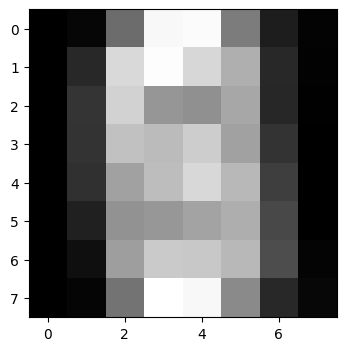

(1077, 65) (360, 65) (360, 65)


In [34]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 

plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((8, 8)), cmap='gray') 
plt.show()

X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape)

2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py



In [35]:
from scripts.classifiers.linear_svm import svm_loss_naive, svm_loss_vectorized
import time
num_dev = 500
mask = np.random.choice(X_train.shape[0], num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]
W = np.random.randn(X_dev.shape[1], 10) * 0.0001 
loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

loss: 9.002288



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [36]:
from scripts.gradient_check import grad_check_sparse
loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: 1.518949 analytic: 1.518949, relative error: 5.386034e-11
numerical: -4.589647 analytic: -4.589647, relative error: 4.270802e-11
numerical: 1.299025 analytic: 1.299025, relative error: 2.022204e-10
numerical: 0.092009 analytic: 0.092009, relative error: 6.387766e-10
numerical: 5.960825 analytic: 5.960825, relative error: 2.742952e-11
numerical: -0.472002 analytic: -0.472002, relative error: 5.894926e-11
numerical: -2.215783 analytic: -2.215783, relative error: 1.745574e-10
numerical: -3.948704 analytic: -3.948704, relative error: 4.556001e-11
numerical: 4.264039 analytic: 4.264039, relative error: 3.779483e-11
numerical: -0.747898 analytic: -0.747898, relative error: 1.774391e-10
numerical: -0.015876 analytic: -0.015876, relative error: 1.989875e-08
numerical: 0.550554 analytic: 0.550554, relative error: 8.179197e-10
numerical: 2.006374 analytic: 2.006374, relative error: 1.110440e-10
numerical: -4.967280 analytic: -4.967280, relative error: 7.247776e-11
numerical: -4.917851

2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [37]:
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.012717s
Vectorized loss and gradient: computed in 0.000527s
difference: 0.000000


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [38]:
from scripts.classifiers import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 25.034297
iteration 100 / 1500: loss 14.844904
iteration 200 / 1500: loss 11.124558
iteration 300 / 1500: loss 9.746970
iteration 400 / 1500: loss 9.242542
iteration 500 / 1500: loss 9.057287
iteration 600 / 1500: loss 8.990591
iteration 700 / 1500: loss 8.969747
iteration 800 / 1500: loss 8.955666
iteration 900 / 1500: loss 8.951743
iteration 1000 / 1500: loss 8.951552
iteration 1100 / 1500: loss 8.951276
iteration 1200 / 1500: loss 8.951477
iteration 1300 / 1500: loss 8.950919
iteration 1400 / 1500: loss 8.947144
That took 0.165660s


In [39]:
y_train_pred = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.867224
validation accuracy: 0.858333


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [40]:
learning_rates = [1e-3, 1e-4, 1e-5]
regularization_strengths = [0.1, 1.0, 10.0, 100.0]
results = {}
best_val = -1
best_svm = None
for lr in learning_rates:
    for rs in regularization_strengths:
        svm = LinearSVM()
        svm.train(X_train, y_train, learning_rate=lr, reg=rs, num_iters=1500, verbose=False)
        y_train_pred = svm.predict(X_train)
        train_accuracy = np.mean(y_train == y_train_pred)
        y_val_pred = svm.predict(X_val)
        val_accuracy = np.mean(y_val == y_val_pred)
        results[(lr, rs)] = (train_accuracy, val_accuracy)
        if val_accuracy > best_val:
            best_val = val_accuracy
            best_svm = svm

for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))
    
print('best validation accuracy: %f' % best_val)

y_test_pred = best_svm.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('best linear SVM test accuracy: %f' % test_accuracy)

lr 1.000000e-05 reg 1.000000e-01 train accuracy: 0.938719 val accuracy: 0.916667
lr 1.000000e-05 reg 1.000000e+00 train accuracy: 0.939647 val accuracy: 0.925000
lr 1.000000e-05 reg 1.000000e+01 train accuracy: 0.936862 val accuracy: 0.916667
lr 1.000000e-05 reg 1.000000e+02 train accuracy: 0.922934 val accuracy: 0.897222
lr 1.000000e-04 reg 1.000000e-01 train accuracy: 0.971216 val accuracy: 0.952778
lr 1.000000e-04 reg 1.000000e+00 train accuracy: 0.969359 val accuracy: 0.955556
lr 1.000000e-04 reg 1.000000e+01 train accuracy: 0.960074 val accuracy: 0.944444
lr 1.000000e-04 reg 1.000000e+02 train accuracy: 0.920149 val accuracy: 0.908333
lr 1.000000e-03 reg 1.000000e-01 train accuracy: 0.986072 val accuracy: 0.963889
lr 1.000000e-03 reg 1.000000e+00 train accuracy: 0.977716 val accuracy: 0.961111
lr 1.000000e-03 reg 1.000000e+01 train accuracy: 0.962860 val accuracy: 0.952778
lr 1.000000e-03 reg 1.000000e+02 train accuracy: 0.907149 val accuracy: 0.891667
best validation accuracy: 0.

2.9 Сделайте выводы по второй части задания

Итоговая точность svm на тестовой выборке составила 96,11%. Этот результат сопоставим с результатом KNN хоть и немного меньше. При этом SVM продемонстрировал значительное преимущество перед KNN в скорости работы на этапе предсказания, так как классификация сводится к одной операции матричного умножения.   
Кросс-валидация показала высокую чувствительность модели к скорости обучения и силе регуляризации. Оптимальными параметрами были признаны lr = 1e-03 и reg = 0.1, обеспечившие точность на валидации 96,39%.   
Использование L2-регуляризации позволило эффективно контролировать норму весов $W$, предотвращая переобучение модели и стабилизируя процесс минимизации функции потерь.   
Реализация векторизованного расчета потерь и градиента обеспечила ускорение вычислений примерно в 10 раз по сравнению с наивным подходом.   
Линейный SVM является подходящим и быстрым инструментом для классификации данных, имеющих четкую линейную разделимость. Однако для работы с более сложными, зашумленными изображениями или данными с нелинейными границами классов может потребоваться переход к нейронным сетям или использование ядерных методов.